# Notebook 10 - Target Variable Analysis

Dataset: customer_churn.csv (telecom customer churn data)
The target column in this dataset is Churn. It tells us whether a customer left the company (Yes) or stayed (No). Since this is a classification problem (two classes, not a number), we look at class distribution, counts, percentages and imbalance rather than mean/variance style stats.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("custumer.csv")
df['Churn'].head()

0    Yes
1     No
2     No
3     No
4    Yes
Name: Churn, dtype: object

## 1. Why the Target Needs Its Own Analysis

### Concept
The target variable is the column we eventually want a model to predict. Every other column is only useful in relation to how well it explains the target, so before going deeper into feature relationships it helps to fully understand the target on its own first.

### Example
If 95 out of 100 patients in a disease-prediction dataset are healthy, a model that always predicts "healthy" would be right 95% of the time and still be completely useless for actually detecting disease. You can only catch a problem like this by looking at the target first.

### Why it matters for AI/ML
Knowing the target's shape up front decides things like which evaluation metric to use, whether resampling is needed, and what a "good" model score should even look like.

## 2. Class Counts

### Concept
Since Churn is categorical with two possible values, the first step is simply counting how many rows fall into each class.

### Example
Counting how many customers have Churn = Yes and how many have Churn = No.

In [4]:
df['Churn'].value_counts()

Churn
No     3565
Yes    1455
Name: count, dtype: int64

**Interpretation:** 3565 customers did not churn (No) and 1455 customers churned (Yes), out of 5020 total customers.

**Insight:** The two classes are not close to equal, which we look at more closely below.

## 3. Class Percentages

### Concept
Turning the raw counts into percentages of the total makes the split easier to talk about and compare against other datasets.

### Why it matters
"29% churn rate" is a number that can be tracked over time or compared across regions/products, while "1455 customers" on its own isn't as useful without knowing the total.

In [5]:
churn_pct = df['Churn'].value_counts(normalize=True) * 100
churn_pct.round(2)

Churn
No     71.02
Yes    28.98
Name: proportion, dtype: float64

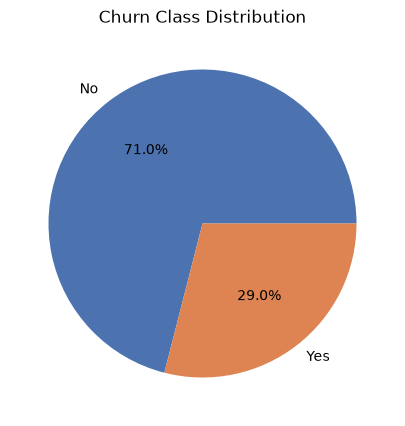

In [6]:
plt.figure(figsize=(5,5))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'])
plt.ylabel('')
plt.title('Churn Class Distribution')
plt.show()

**Interpretation:** About 71% of customers stayed and 29% churned.

**Insight:** A 71/29 split is a moderate imbalance - not extreme (like 99/1), but enough that it needs to be accounted for when we get to modeling.

## 4. Class Imbalance

### Concept
Class imbalance means one class has noticeably more records than the other. There's no fixed rule for when a split "counts" as imbalanced, but anything further from 50/50 than roughly 60/40 is usually worth flagging.

### Example
A fraud detection dataset might be 99% "not fraud" and 1% "fraud" - that is a severe imbalance. Our Churn split (71/29) is a moderate imbalance, not as extreme as fraud detection but still real.

### Why it matters
With an imbalanced target:
- Accuracy alone is a misleading metric, because always predicting the majority class gives a high accuracy score without the model actually learning anything.
- Metrics like precision, recall, F1-score, or ROC-AUC give a truer picture.
- Techniques like class weighting, oversampling (SMOTE) or undersampling may be needed at model-training time.

In [8]:
majority_class_baseline = df['Churn'].value_counts(normalize=True).max() * 100
print(f"If a model always predicted the majority class, it would score {majority_class_baseline:.2f}% accuracy without learning anything.")

If a model always predicted the majority class, it would score 71.02% accuracy without learning anything.


**Interpretation:** A model that just guesses "No" every time would already be right about 71% of the time. That number is not a real benchmark for a useful model.

**Insight:** Accuracy by itself should not be trusted as the main metric for this target. Recall (catching customers who will actually churn) is probably more important for the business than raw accuracy, since missing a churner has a real cost.

## 5. Numerical Features vs Target (Quick Look)

### Concept
Even though the target itself is categorical, it helps to see how the mean of a few important numerical columns differs between the two Churn classes. This is a preview of what the Bivariate notebook covers in more depth, but it belongs here too because it's part of understanding the target.

### Why it matters
If a numerical feature has very different averages between the two classes, that feature is likely to be a strong predictor.

In [9]:
num_cols = ['Age', 'TenureYears', 'MonthlyCharges', 'TotalCharges', 'SupportCalls']
df.groupby('Churn')[num_cols].mean().round(2)

,Age,TenureYears,MonthlyCharges,TotalCharges,SupportCalls
Churn,,,,,
No,43.09,4.96,69.31,4172.11,2.10
Yes,43.92,4.78,69.90,4013.97,2.11


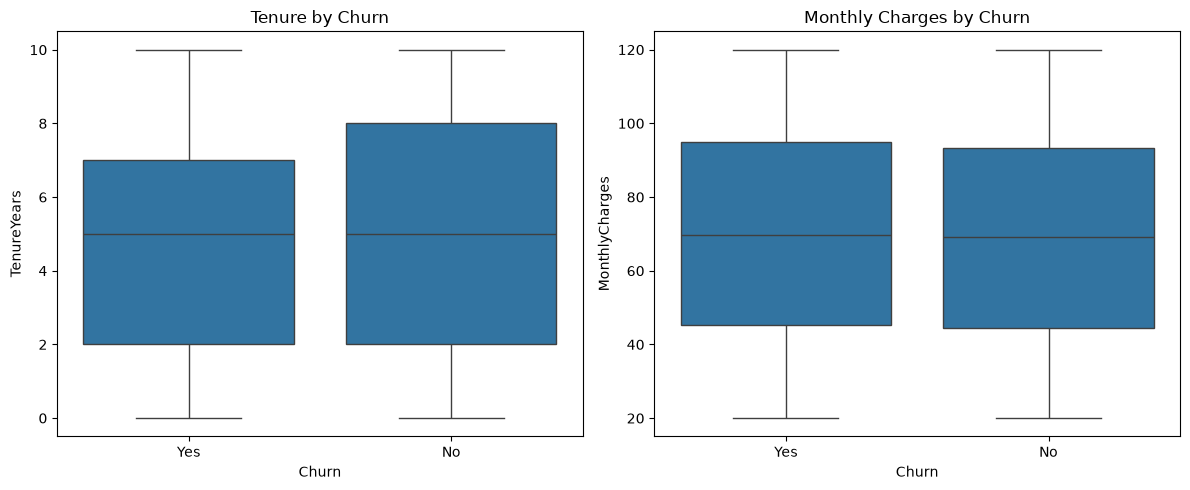

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df, x='Churn', y='TenureYears', ax=axes[0])
axes[0].set_title('Tenure by Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges by Churn')
plt.tight_layout()
plt.show()

**Interpretation:** Customers who churned have a lower average TenureYears than customers who stayed, meaning newer customers churn more. Churned customers also tend to have somewhat higher MonthlyCharges and more SupportCalls on average.

**Insight:** TenureYears, MonthlyCharges and SupportCalls all look like promising predictors and should be examined more closely in the Bivariate Analysis notebook.

### AI/ML Relevance
Understanding the target before modeling decides three things directly: which evaluation metric to trust (not plain accuracy, given the imbalance), whether the training data needs rebalancing, and which features are worth prioritizing based on how differently they behave across the two classes.